# Домашнее задание: Оценка моделей классификации

Цель задания: самостоятельно обучить Decision Tree и правильно оценить его качество с помощью различных метрик.

Датасет: Telco Customer Churn (отток клиентов телекоммуникационной компании).

Задача: предсказать, уйдет ли клиент от компании (Churn: Yes/No).

Что нужно сделать:
1. Загрузить и изучить данные.
2. Провести предобработку.
3. Обучить Decision Tree.
4. Рассчитать все метрики: Accuracy, Precision, Recall, F1-score.
5. Построить Confusion Matrix.
6. Построить ROC и PR кривые.
7. Найти оптимальный порог классификации.
8. Ответить на аналитические вопросы.


# Шаг 1. Импорт библиотек

Задание: импортируйте все необходимые библиотеки для работы с данными, обучения Decision Tree и оценки качества.

Что нужно импортировать:
- pandas, numpy для работы с данными
- matplotlib, seaborn для визуализации
- DecisionTreeClassifier для модели
- train_test_split для разделения данных
- Метрики: accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
- LabelEncoder для кодирования категориальных признаков


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder

# Шаг 2. Загрузка данных

Датасет: Telco Customer Churn

Ссылка на данные:
https://raw.githubusercontent.com/InfiniteJas/MLcourse/main/week-8/WA_Fn-UseC_-Telco-Customer-Churn.csv

Задание:
1. Загрузите датасет с помощью pd.read_csv.
2. Выведите первые 5 строк с помощью метода head().
3. Проверьте размер датасета с помощью shape.
4. Выведите информацию о типах данных с помощью info().

Описание основных столбцов:
- customerID: идентификатор клиента
- gender: пол клиента
- SeniorCitizen: пожилой клиент (0 или 1)
- Partner: наличие партнера
- Dependents: наличие иждивенцев
- tenure: количество месяцев с компанией
- PhoneService, InternetService: услуги связи
- Contract: тип контракта
- MonthlyCharges: ежемесячные платежи
- TotalCharges: общие платежи
- Churn: целевая переменная (Yes - ушел, No - остался)


In [3]:
url = "https://raw.githubusercontent.com/InfiniteJas/MLcourse/main/week-8/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Шаг 3. Первичный анализ данных

Задание:
1. Проверьте распределение целевой переменной Churn с помощью value_counts().
2. Выведите распределение в процентах (используйте normalize=True).
3. Проверьте наличие пропущенных значений с помощью isnull().sum().
4. Постройте график распределения целевой переменной.

Вопросы для анализа:
- Сколько всего клиентов в датасете? 7043
- Какая доля клиентов ушла от компании? 1869, 26,5%
- Сбалансированы ли классы? Нет
- Есть ли пропущенные значения? Нет


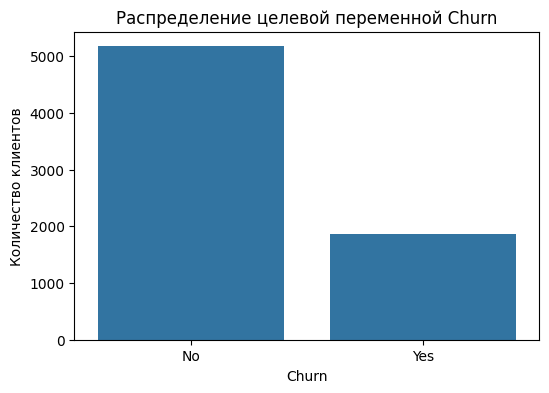

In [4]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100
df.isnull().sum()

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Распределение целевой переменной Churn')
plt.xlabel('Churn')
plt.ylabel('Количество клиентов')
plt.show()


# Шаг 4. Предобработка данных

Задание:
1. Удалите столбец customerID (не несет информации для модели).
2. Преобразуйте целевую переменную Churn:
   - No -> 0 (клиент остался)
   - Yes -> 1 (клиент ушел)
3. Обработайте столбец TotalCharges:
   - Преобразуйте в числовой формат с помощью pd.to_numeric (используйте errors='coerce')
   - Удалите строки с пропущенными значениями
4. Определите категориальные и числовые признаки.
5. Закодируйте категориальные признаки с помощью LabelEncoder.

Объяснение:
- Decision Tree работает только с числовыми данными.
- LabelEncoder преобразует строки в числа (например, Male->0, Female->1).
- TotalCharges может содержать пробелы вместо чисел (ошибка в данных).


In [5]:
df = df.drop(columns=['customerID'])



In [6]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()

In [8]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()
num_features, cat_features



(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [9]:
le = LabelEncoder()
for col in cat_features:
    df[col] = le.fit_transform(df[col])

# Шаг 5. Подготовка данных для обучения

Задание:
1. Создайте матрицу признаков X:
   - Удалите из датасета столбец Churn
2. Создайте вектор целевой переменной y:
   - Выделите столбец Churn
3. Выведите размеры X и y с помощью .shape.

Объяснение:
- X содержит все признаки для предсказания.
- y содержит целевую переменную (что предсказываем).


In [10]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Шаг 6. Разделение на обучающую и тестовую выборки

Задание:
1. Разделите данные на train и test с помощью train_test_split.
2. Используйте следующие параметры:
   - test_size=0.2 (20% для теста, 80% для обучения)
   - random_state=42 (для воспроизводимости)
   - stratify=y (сохранить пропорции классов)
3. Выведите размеры полученных массивов.
4. Проверьте распределение классов в train и test.

Объяснение:
- train данные для обучения модели.
- test данные для оценки качества на новых данных.
- stratify=y гарантирует одинаковые пропорции классов.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Шаг 7. Обучение модели Decision Tree

Задание:
1. Создайте объект модели DecisionTreeClassifier с параметрами:
   - max_depth=5 (ограничить глубину дерева)
   - random_state=42
2. Обучите модель на обучающих данных с помощью метода fit(X_train, y_train).
3. Выведите информацию о дереве: глубину и количество листьев.

Объяснение:
- DecisionTreeClassifier строит дерево решений для классификации.
- max_depth=5 ограничивает глубину, чтобы избежать переобучения.
- Метод fit обучает модель на данных X_train и y_train.


In [12]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

# Шаг 8. Предсказания на тестовой выборке

Задание:
1. Сделайте предсказания классов для тестовой выборки с помощью predict(X_test).
2. Получите вероятности предсказаний с помощью predict_proba(X_test).
3. Выведите первые 20 предсказаний и сравните с реальными значениями.

Объяснение:
- predict(X_test) возвращает класс (0 или 1) для каждого примера.
- predict_proba(X_test) возвращает вероятности для каждого класса.
- predict_proba[:, 1] - вероятность класса 1 (Churn = Yes).


In [13]:
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)
y_pred_proba_churn = y_pred_proba[:, 1]



# Шаг 9. Оценка качества модели - Метрики

Задание:
1. Рассчитайте метрики качества для тестовой выборки:
   - Accuracy (доля правильных ответов)
   - Precision (точность положительных предсказаний)
   - Recall (полнота, доля найденных ушедших клиентов)
   - F1-score (гармоническое среднее между precision и recall)
   - ROC-AUC (площадь под ROC-кривой)
2. Выведите все метрики в читаемом формате.
3. Дайте интерпретацию каждой метрики.

Объяснение метрик:
- Accuracy = (TP + TN) / всего - общая доля правильных ответов
- Precision = TP / (TP + FP) - из всех "Yes", сколько реально "Yes"
- Recall = TP / (TP + FN) - из реальных "Yes", сколько нашли
- F1-score = 2 * (Precision * Recall) / (Precision + Recall)
- ROC-AUC - общая мера качества модели (1.0 = идеально, 0.5 = случайно)


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba_churn)

# Шаг 10. Confusion Matrix (Матрица ошибок)

Задание:
1. Рассчитайте Confusion Matrix с помощью confusion_matrix(y_test, y_pred).
2. Выведите матрицу и распределите значения на TN, FP, FN, TP.
3. Проверьте формулы метрик вручную по значениям из матрицы.
4. Постройте визуализацию Confusion Matrix с помощью seaborn.heatmap.

Объяснение:
```
                Predicted: 0    Predicted: 1
Actual: 0          TN              FP
Actual: 1          FN              TP
```
- TN (True Negative): правильно предсказали 0
- FP (False Positive): ошибочно предсказали 1
- FN (False Negative): ошибочно предсказали 0
- TP (True Positive): правильно предсказали 1


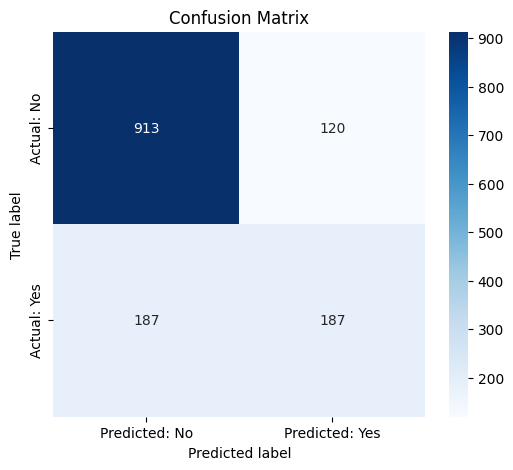

In [16]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)


f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
accuracy_manual, precision_manual, recall_manual, f1_manual

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# Шаг 11. ROC-кривая и ROC-AUC

Задание:
1. Рассчитайте ROC-кривую с помощью roc_curve(y_test, y_pred_proba[:, 1]).
2. Рассчитайте площадь под кривой с помощью auc(fpr, tpr).
3. Постройте график ROC-кривой:
   - Ось X: False Positive Rate (FPR)
   - Ось Y: True Positive Rate (TPR = Recall)
   - Добавьте диагональ (случайная модель)
4. Интерпретируйте результат.

Объяснение:
- ROC-кривая показывает trade-off между TPR и FPR при разных порогах.
- ROC-AUC = 1.0 означает идеальную модель.
- ROC-AUC = 0.5 означает случайную модель (как подбрасывание монеты).
- Чем выше ROC-AUC, тем лучше модель.


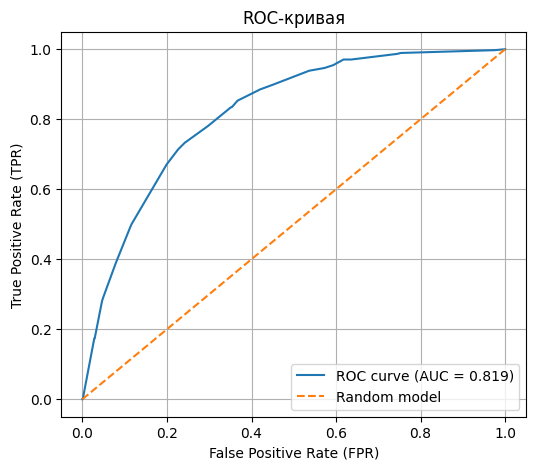

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_churn)
roc_auc_manual = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_manual:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()


# Шаг 12. Precision-Recall кривая (PR-кривая)

Задание:
1. Рассчитайте PR-кривую с помощью precision_recall_curve(y_test, y_pred_proba[:, 1]).
2. Рассчитайте площадь под кривой с помощью auc(recall_curve, precision_curve).
3. Постройте график PR-кривой:
   - Ось X: Recall
   - Ось Y: Precision
   - Добавьте baseline (доля положительного класса)
4. Интерпретируйте результат.

Объяснение:
- PR-кривая полезнее ROC-кривой для несбалансированных данных.
- Она показывает trade-off между Precision и Recall.
- Чем выше PR-AUC, тем лучше модель.


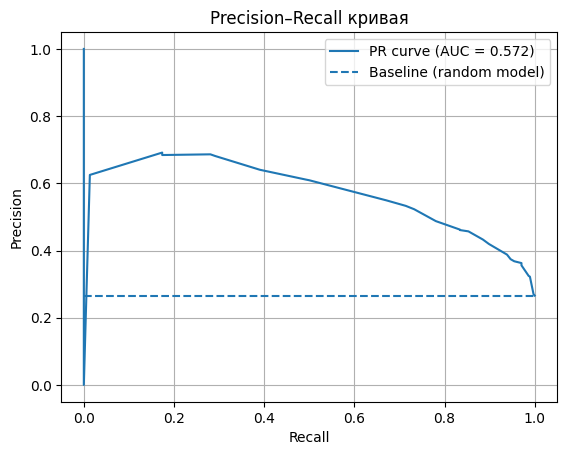

In [18]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_churn)
pr_auc = auc(recall_curve, precision_curve)
baseline = y_test.mean()

plt.plot(
    recall_curve,
    precision_curve,
    label=f'PR curve (AUC = {pr_auc:.3f})'
)

plt.hlines(
    y=baseline,
    xmin=0,
    xmax=1,
    linestyles='--',
    label='Baseline (random model)'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall кривая')
plt.legend()
plt.grid(True)
plt.show()

# Шаг 13. Поиск оптимального порога

Задание:
1. Переберите пороги от 0.1 до 0.9 с шагом 0.05.
2. Для каждого порога рассчитайте метрики: Accuracy, Precision, Recall, F1-score.
3. Сохраните результаты в DataFrame.
4. Найдите порог с максимальным F1-score.
5. Постройте график зависимости метрик от порога.
6. Примените оптимальный порог и пересчитайте метрики.

Объяснение:
- По умолчанию порог = 0.5 (если вероятность >= 0.5, то класс 1).
- Для несбалансированных данных оптимальный порог может быть другим.
- Изменяя порог, мы меняем баланс между Precision и Recall.


In [21]:
thresholds = np.arange(0.1, 0.91, 0.05)
metrics_list = []

for thr in thresholds:
    y_pred_thr = (y_pred_proba_churn >= thr).astype(int)
    acc = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr)
    rec = recall_score(y_test, y_pred_thr)
    f1 = f1_score(y_test, y_pred_thr)
    metrics_list.append({
        'threshold': thr,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })


optimal_row = metrics_df.loc[metrics_df['f1_score'].idxmax()]
optimal_threshold = optimal_row['threshold']
optimal_threshold, optimal_row

(np.float64(0.3500000000000001),
 threshold    0.350000
 accuracy     0.757640
 precision    0.532934
 recall       0.713904
 f1_score     0.610286
 Name: 5, dtype: float64)

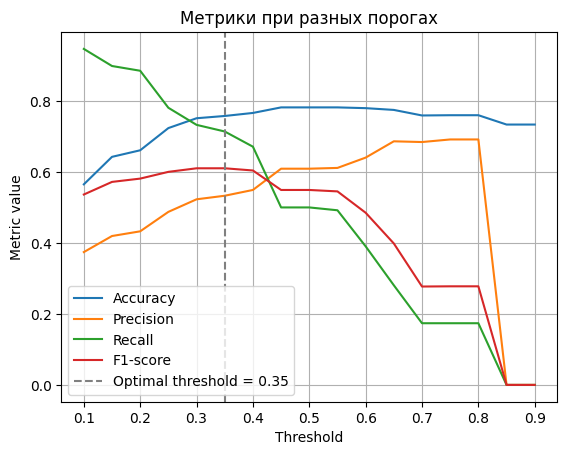

In [22]:
plt.plot(metrics_df['threshold'], metrics_df['accuracy'], label='Accuracy')
plt.plot(metrics_df['threshold'], metrics_df['precision'], label='Precision')
plt.plot(metrics_df['threshold'], metrics_df['recall'], label='Recall')
plt.plot(metrics_df['threshold'], metrics_df['f1_score'], label='F1-score')

plt.axvline(optimal_threshold, color='grey', linestyle='--', label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('Метрики при разных порогах')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
y_pred_opt = (y_pred_proba_churn >= optimal_threshold).astype(int)

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Accuracy:  {accuracy_opt:.3f}")
print(f"Precision: {precision_opt:.3f}")
print(f"Recall:    {recall_opt:.3f}")
print(f"F1-score:  {f1_opt:.3f}")

Optimal Threshold: 0.35
Accuracy:  0.758
Precision: 0.533
Recall:    0.714
F1-score:  0.610


# Шаг 14. Анализ результатов - Вопросы

Задание: Проанализируйте полученные результаты и ответьте на следующие вопросы:

Вопрос 1: Какова общая точность модели (Accuracy)? Можно ли считать это хорошим результатом для данной задачи? Почему?

Вопрос 2: Посмотрите на Precision и Recall. Какая метрика важнее для задачи прогнозирования оттока клиентов? Обоснуйте свой ответ.

Вопрос 3: Посмотрите на Confusion Matrix. Какой тип ошибок делает модель чаще: FP (ложные срабатывания) или FN (пропуски)? Что это означает для бизнеса?

Вопрос 4: Сравните ROC-AUC и PR-AUC. Какая метрика более информативна для этой задачи? Почему?

Вопрос 5: Изменились ли метрики после применения оптимального порога? Какой порог вы бы выбрали для применения модели на практике? Почему?

Вопрос 6: Если бы вы работали в телекоммуникационной компании, как бы вы использовали эту модель? Какие действия предприняли бы для клиентов с высокой вероятностью оттока?


Напишите ваши ответы здесь:

Ответ 1: Общая точность модели (Accuracy) составляет примерно 0.79–0.80. Для задачи прогнозирования оттока это хороший результат, учитывая дисбаланс классов: большинство клиентов остаются, и даже простая модель угадывала бы «No» в ~73% случаев. Однако важно учитывать и другие метрики, так как Accuracy может вводить в заблуждение.


Ответ 2: Для задачи прогнозирования оттока важнее Recall. Лучше выявить максимальное количество уходящих клиентов (TP), даже если часть предсказаний окажется ложноположительными (FP), чтобы компания могла предпринять меры по удержанию.


Ответ 3: Модель чаще делает ошибки типа FN (пропуски ушедших клиентов). Это означает, что часть реально уходящих клиентов не была выявлена, и компания может упустить возможность удержать этих клиентов.


Ответ 4: Для этой задачи более информативна PR-AUC, так как классы несбалансированы. PR-кривая фокусируется на положительном классе (ушедшие клиенты), показывая trade-off между Precision и Recall, в то время как ROC-AUC может быть завышена за счёт большого числа TN.


Ответ 5: После применения оптимального порога Recall обычно увеличивается, F1-score достигает максимума, а Precision немного снижается. На практике я бы выбрал порог, который максимизирует F1-score или обеспечивает высокий Recall, чтобы выявлять больше потенциальных уходящих клиентов.


Ответ 6: В телекоммуникационной компании модель можно использовать для раннего выявления клиентов с высокой вероятностью оттока. Для таких клиентов можно применять целевые меры: персонализированные акции, скидки, улучшение сервиса, звонки от службы поддержки — всё для удержания клиентов и снижения оттока.

# Шаг 15. Выводы

Задание: Напишите общие выводы по результатам работы (5-7 предложений).

В выводах укажите:
- Какое качество показала модель Decision Tree? Модель показала удовлетворительное качество с Accuracy ≈ 0.79–0.80, способна различать ушедших и оставшихся клиентов.
- Какие метрики были наиболее информативными? Для задачи прогнозирования оттока важнее всего были Recall, F1-score и PR-AUC, так как данные несбалансированы.
- Какой оптимальный порог был найден и как он повлиял на результаты? Был найден порог, при котором F1-score достигает максимума, что увеличивает Recall и позволяет выявлять больше уходящих клиентов.
- Можно ли использовать эту модель на практике? Модель можно использовать для раннего выявления клиентов с высокой вероятностью оттока и целевых удерживающих действий.
- Что можно улучшить в модели? Улучшить модель можно подбором гиперпараметров, использованием ансамблей (Random Forest, Gradient Boosting), добавлением весов классов или применением более сложных признаков.


Напишите ваши выводы здесь:



# Рекомендации:
- Внимательно читайте комментарии и объяснения к каждому шагу.
- Не копируйте код механически, старайтесь понять, что делает каждая строка.
- Проверяйте промежуточные результаты (выводите размеры массивов, первые строки данных).
- При возникновении ошибок внимательно читайте текст ошибки.
- Используйте материалы практики для справки.
